# VerInf / Ligero — verification parameters: equations, optima, validation

Ligero lets a prover convince a verifier that it ran an LLM's forward pass
honestly — without revealing the weights, the inputs, or the activations, and at a
verification cost far below re-running the model. It does so by writing the whole
computation as a system of exact equations over a finite field, committing the
solution (the *witness*), and proving the equations hold by opening a few random
points of an error-correcting encoding of that witness.

This notebook derives every parameter that governs such a proof, recomputes each
one for a demonstrated 400-billion-parameter run, and finds each optimum with a
plot. It is self-contained: all symbols are defined here (Section 0), and no other
document is needed to read it.

## 0. Notation

Every quantity used below, defined once. The "run value" column is the
demonstrated Llama-4-Maverick proof, shown as a table in the next cell.

| symbol | meaning |
|---|---|
| $p,\ \lvert F\rvert$ | the field modulus and size — Goldilocks $p = 2^{64}-2^{32}+1 \approx 2^{64}$ |
| $s$ | fixed-point scale: a real $x$ is stored as the integer $\mathrm{round}(s\,x)$ |
| $W$ | witness length — total number of field elements the prover commits |
| $Q,\ L$ | number of quadratic (multiplication) and linear (addition) constraints |
| $M$ | number of lookup-table accesses (for $\exp$, SiLU, rsqrt) over the run |
| $n_{\mathrm{mm}}$ | number of matrix multiplications (each checked by Freivalds) |
| $S$ | number of tokens in the transcript |
| $K$ | row length — the witness is packed into rows of $K$ slots |
| $\text{ELL}$ | payload slots per row (the actual witness data) |
| $\text{pad}$ | random masking slots per row; $K = \text{ELL} + \text{pad}$ |
| $\rho$ | Reed–Solomon inverse rate (blow-up); each row of $K$ becomes a codeword of $N=\rho K$ |
| $N$ | codeword length $=\rho K$ = number of columns committed |
| $m$ | number of rows $= W/\text{ELL}$ |
| $\lambda$ | geometric cost multiplier $= K/\text{ELL}$ |
| $T$ | number of columns the verifier opens — this sets the soundness |
| $Q_c$ | number of proofs served by one commitment (masking must cover $T\,Q_c$) |
| $\varepsilon$ | cheating probability; "soundness in bits" means $-\log_2\varepsilon$ |
| $c(n)$ | measured NTT cost, nanoseconds per element at transform length $n$ |
| $h$ | BLAKE3 compression time (8 elements per compression) |
| $R,\ R_{\max}$ | largest activation magnitude / the representable bound |

In [1]:
import sys, math, importlib, contextlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.float_format", lambda v: f"{v:,.4g}")

# The prover's measured cost model — a pure-`math` module (no GPU, no torch),
# imported and reused rather than re-derived.
sys.path.insert(0, "/home/riftuser/VerInf/analysis")
import ligero_param_derivation as lpd
importlib.reload(lpd)

# Colorblind-safe categorical palette, fixed order (never cycled).
PAL = ["#2a78d6", "#008300", "#e87ba4", "#eda100",
       "#1baf7a", "#eb6834", "#4a3aa7", "#e34948"]
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#d9d8d4"
plt.rcParams.update({
    "figure.dpi": 120, "figure.figsize": (8, 4.6),
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
})

P = 2**64 - 2**32 + 1                      # Goldilocks prime, |F| ≈ 2^64
F = float(P)

### The demonstrated run

The parameters and cost drivers of the proof that this notebook recomputes.

In [2]:
RUN = dict(W=9.44e11, Q=1.93e11, L=1.79e11, S=1093, n_mm=9500,
           ELL=8192, pad=8192, K=2**14, rho=4, N=2**16, T=40, lam=2.0,
           W_weights=4.00e11, s_fp=2**12, c_ref=0.42, h_ns=0.5)

run_tbl = pd.DataFrame([
    ("W",   RUN["W"],   "witness length (field elements)"),
    ("Q",   RUN["Q"],   "quadratic constraints (multiplications)"),
    ("L",   RUN["L"],   "linear constraints (additions)"),
    ("S",   RUN["S"],   "tokens in the transcript"),
    ("n_mm",RUN["n_mm"],"matrix multiplications"),
    ("K",   RUN["K"],   "row length"),
    ("ELL", RUN["ELL"], "payload slots per row"),
    ("pad", RUN["pad"], "masking slots per row"),
    ("rho", RUN["rho"], "RS inverse rate; N = rho·K"),
    ("N",   RUN["N"],   "codeword length = columns committed"),
    ("T",   RUN["T"],   "opened columns (soundness)"),
    ("lambda", RUN["lam"], "cost multiplier K/ELL"),
    ("s",   RUN["s_fp"],"fixed-point scale"),
], columns=["symbol","value","meaning"]).set_index("symbol")
run_tbl

,value,meaning
symbol,,
W,9.44e+11,witness length (field elements)
Q,1.93e+11,quadratic constraints (multiplications)
L,1.79e+11,linear constraints (additions)
S,"1,093",tokens in the transcript
n_mm,"9,500",matrix multiplications
K,1.638e+04,row length
ELL,"8,192",payload slots per row
pad,"8,192",masking slots per row
rho,4,RS inverse rate; N = rho·K


## 1. Field and fixed-point arithmetic

Real numbers enter the field as fixed-point integers $\hat x = \mathrm{round}(s\,x)$.
Two independent facts pin the field and the scale.

**The field size is forced.** A length-$k$ dot product sums $k$ products, each up
to $(sR)^2$, where $R$ is the largest activation magnitude. To avoid wraparound
the modulus must exceed the largest intermediate — equivalently, its width in bits
must cover

$$b \;=\; \log_2 k \;+\; 2\log_2 s \;+\; 2\log_2 R \;+\; 1\ (\text{sign bit}).$$

The table below evaluates $b$. At the run's worst-case dot length it lands just
above 46 bits — past every 31-bit field (M31, BabyBear), and still past them even
after shrinking $s$ to $2^6$. The smallest machine word that fits is 64-bit, and
Goldilocks is the unique 64-bit prime carrying the NTT's roots of unity. The
`bits` column is the value of $b$; the modulus must exceed it.

In [3]:
def field_bits(k, s, R):
    return math.log2(k) + 2*math.log2(s) + 2*math.log2(R) + 1     # required modulus width

s, R = RUN["s_fp"], 8
field_tbl = pd.DataFrame([
    dict(scenario="run: k = T·S",         k=RUN["T"]*RUN["S"], s=s,    R=R),
    dict(scenario="1e6-token context",    k=40*10**6,          s=s,    R=R),
    dict(scenario="31-bit field, s→2^6",  k=RUN["T"]*RUN["S"], s=2**6, R=R),
])
field_tbl["log2 k"]   = np.log2(field_tbl["k"])
field_tbl["bits b"]   = [field_bits(r.k, r.s, r.R) for r in field_tbl.itertuples()]
field_tbl["fits 31-bit?"] = field_tbl["bits b"] < 31
field_tbl.set_index("scenario")

,k,s,R,log2 k,bits b,fits 31-bit?
scenario,,,,,,
run: k = T·S,43720,4096,8,15.42,46.42,False
1e6-token context,40000000,4096,8,25.25,56.25,False
"31-bit field, s→2^6",43720,64,8,15.42,34.42,False


**Fixed-point scale $s$.** The no-wraparound condition $k\,s^2R^2 < 2^{63}$ caps the
dot length; the run keeps large headroom (below). Accuracy is the second,
independent criterion, and it plateaus at $s = 2^{12}$ — optimal on both counts.
The accuracy figures are measured top-1 rates from the model-accuracy sweep.

In [4]:
def dot_ceiling_bits(s, R): return 63 - (2*math.log2(s) + 2*math.log2(R))   # max log2 k

headroom = pd.DataFrame([
    dict(quantity="max dot length  log2 k <",      bits=dot_ceiling_bits(s, R)),
    dict(quantity="run dot length   log2(T·S)",    bits=math.log2(RUN["T"]*RUN["S"])),
    dict(quantity="headroom (run)",                bits=dot_ceiling_bits(s,R)-math.log2(RUN["T"]*RUN["S"])),
    dict(quantity="headroom (1e6 ctx)",            bits=dot_ceiling_bits(s,R)-math.log2(40*10**6)),
]).set_index("quantity")

accuracy = pd.DataFrame({
    "setting": ["s = 2^10", "s = 2^12 (chosen)", "s = 2^12, clip 32→20"],
    "top-1 %": [92.99, 96.70, 99.45],
    "note": ["baseline", "accuracy plateau begins", "the clip bound, not s, drives the last gain"],
}).set_index("setting")
display(headroom); accuracy

,bits
quantity,
max dot length log2 k <,33
run dot length log2(T·S),15.42
headroom (run),17.58
headroom (1e6 ctx),7.747


,top-1 %,note
setting,,
s = 2^10,92.99,baseline
s = 2^12 (chosen),96.7,accuracy plateau begins
"s = 2^12, clip 32→20",99.45,"the clip bound, not s, drives the last gain"


**Bit-width $w$ and table resolution.** Range-checks bound activations to
$\pm 2^{w-1}$, so the representable range is $R = 2^{w-1}/s$ and
$w = 1 + \log_2 s + \log_2 R_{\max}$. A lookup table on $[-x_{\max}, x_{\max}]$
needs $T_{\text{tbl}} \ge 2 s\,x_{\max}$ to be no coarser than the fixed-point grid.
The three historical $w$ settings reproduce exactly; the current table size is
slightly under the requirement, but accuracy is bound by the clip $x_{\max}$, not
by the step.

In [5]:
def bit_width(s, Rmax):   return 1 + math.log2(s) + math.log2(Rmax)
def table_size(s, x_max): return 2*s*x_max

w_tbl = pd.DataFrame([
    dict(w=22, R=2**(22-1)//s, outcome="REJECT — activations overflow (Llama-2)"),
    dict(w=24, R=2**(24-1)//s, outcome="works"),
    dict(w=26, R=2**(26-1)//s, outcome="Maverick (large outliers)"),
])
w_tbl["w recomputed"] = [bit_width(s, r) for r in w_tbl["R"]]

tbl_res = pd.DataFrame([
    dict(quantity="required 2·s·x_max (x_max=20)", log2=math.log2(table_size(s,20))),
    dict(quantity="current table size",            log2=16.0),
]).set_index("quantity")
display(w_tbl.set_index("w")); tbl_res

,R,outcome,w recomputed
w,,,
22,512,REJECT — activations overflow (Llama-2),22
24,2048,works,24
26,8192,Maverick (large outliers),26


,log2
quantity,
required 2·s·x_max (x_max=20),17.32
current table size,16


## 2. The constraint system and test-polynomial degrees

Every multiplication is a **quadratic** constraint (count $Q$), every addition a
**linear** one (count $L$). The prover packs the length-$W$ witness into rows of
$K = \text{ELL} + \text{pad}$ slots — $\text{ELL}$ payload plus $\text{pad}$ random
masking slots — encodes each row as a Reed–Solomon codeword of length $N=\rho K$,
and commits the resulting $m \times N$ matrix by columns.

Three test polynomials batch the checks. A forged test polynomial can agree with
the committed rows in at most $(\text{degree})$ of the $N$ columns, so a forgery is
caught by opening a column outside that agreement set. The degrees, and the
resulting per-column **miss probability** (the chance one opened column fails to
catch a forgery):

$$\deg q_{\text{irs}} \le K-1,\quad
\deg q_{\text{lin}} \le K+\text{ELL}-2,\quad
\deg p_0 \le 2K-2 .$$

The bare gap requirement $2K-2 < N$ is $\rho > 2 - 2/K$, which `ρ = 2` already
satisfies (the gap is exactly 2 points) — so `ρ = 2` is *not* excluded by the gap;
it is excluded in Section 6.3 by the soundness it delivers. The exact quadratic
miss is $(2K-2)/N$; the convenient $2/\rho$ drops the $-2$ and only matches for
large `K`. The table shows both at the run's geometry.

In [6]:
def miss_lin(K, ELL, N):   return (K + ELL - 2) / N
def miss_quad_exact(K, N): return (2*K - 2) / N
def miss_quad(rho):        return 2.0 / rho                # large-K approximation of the above
def miss_irs(rho):         return 1 - (rho - 1) / (3*rho)

deg_tbl = pd.DataFrame([
    dict(test="IRS (each row is a codeword)", degree="K−1",     miss_formula="1 − (ρ−1)/3ρ",
         miss_value=miss_irs(RUN["rho"])),
    dict(test="linear (Σ aᵢxᵢ = 0)",          degree="K+ELL−2", miss_formula="(K+ELL−2)/N",
         miss_value=miss_lin(RUN["K"],RUN["ELL"],RUN["N"])),
    dict(test="quadratic (products)",         degree="2K−2",    miss_formula="(2K−2)/N ≈ 2/ρ",
         miss_value=miss_quad_exact(RUN["K"],RUN["N"])),
]).set_index("test")
deg_tbl

,degree,miss_formula,miss_value
test,,,
IRS (each row is a codeword),K−1,1 − (ρ−1)/3ρ,0.75
linear (Σ aᵢxᵢ = 0),K+ELL−2,(K+ELL−2)/N,0.375
quadratic (products),2K−2,(2K−2)/N ≈ 2/ρ,0.5


## 3. Soundness

After $T$ **independent** column openings the miss probabilities are raised to the
$T$-th power. The IRS term decays slowest, so it alone sets the required $T$:

$$\varepsilon_{\text{IRS}} = \left(\tfrac34\right)^{T},\quad
\varepsilon_{\text{lin}} \le \left(\tfrac38\right)^{T},\quad
\varepsilon_{\text{quad}} = \left(\tfrac12\right)^{T},\qquad
T \ge \frac{s_{\text{bits}}}{\log_2(4/3)} .$$

Each opened column is worth $-\log_2(3/4) \approx 0.415$ bits. Three mechanisms add
a **floor** that does not shrink with $T$: the lookup argument ($M/|F|$), the
constraint folds, and the Freivalds checks ($n_{\text{mm}}\cdot 2/|F|$).

**The fold term depends on how the fold is built, and the choice is load-bearing.**
If the $Q+L$ residuals were folded with powers of a single challenge, $\sum r^i\,
\text{res}_i$, Schwartz–Zippel would give $(Q+L)/|F| \approx 2^{-25.6}$ — which
would *dominate* the lookup floor and cut `T_max` to ~61. But the implementation
folds with an **independent** random coefficient per residual (`_combiner_vec`:
`r[i] = challenge(seed, i, …)`), whose error is $1/|F|$ per fold regardless of the
constraint count. The fold term is then $(N+3)/|F| \approx 2^{-48}$, and the lookup
term is the true floor. Both candidates are shown so the dependence is explicit.

In [7]:
def eps_irs(rho, T):    return miss_irs(rho) ** T
def eps_lin(K,ELL,N,T): return miss_lin(K,ELL,N) ** T
def eps_quad(K,N,T):    return miss_quad_exact(K,N) ** T
def bits_per_col(rho):  return -math.log2(miss_irs(rho))
def T_for_bits(sb, rho=4): return sb / bits_per_col(rho)

def lookup_M(S):
    return dict(SiLU=24*128*8192*S, exp=48*40*S**2, rsqrt=2*48*5120*S)

Mc = lookup_M(RUN["S"]); M = sum(Mc.values())
M_tbl = pd.DataFrame([dict(source=k, accesses=v) for k,v in Mc.items()] +
                     [dict(source="M (total)", accesses=M)]).set_index("source")

# The fold term two ways; the implemented (random-vector) one governs.
fold_powers = (RUN["Q"]+RUN["L"])/F          # if folded by powers of one r — NOT used
fold_vector = (RUN["N"]+3)/F                 # independent random combiners — as implemented
floor = dict(lookup=M/F, fold=fold_vector, freivalds=RUN["n_mm"]*2/F)
floor_tbl = pd.DataFrame([
    dict(mechanism="lookup  M/|F|", probability=floor["lookup"], bits=-math.log2(floor["lookup"]), governs="← FLOOR"),
    dict(mechanism="fold (random vector)  (N+3)/|F|", probability=fold_vector, bits=-math.log2(fold_vector), governs="implemented"),
    dict(mechanism="fold (powers of r)  (Q+L)/|F|", probability=fold_powers, bits=-math.log2(fold_powers), governs="would dominate — NOT used"),
    dict(mechanism="Freivalds  n_mm·2/|F|", probability=floor["freivalds"], bits=-math.log2(floor["freivalds"]), governs=""),
]).set_index("mechanism")
display(M_tbl); floor_tbl

,accesses
source,
SiLU,27506245632
exp,2293726080
rsqrt,537231360
M (total),30337203072


,probability,bits,governs
mechanism,,,
lookup M/|F|,1.645e-09,29.18,← FLOOR
fold (random vector) (N+3)/|F|,3.553e-15,48,implemented
fold (powers of r) (Q+L)/|F|,2.017e-08,25.56,would dominate — NOT used
Freivalds n_mm·2/|F|,1.03e-15,49.79,


The floor sits at $2^{-29.2}$, so the code's `T_QUERIES = 80` (nominally $2^{-33}$)
cannot reach its target. But there is a subtler point the naive reading misses:
because the floor is a *lower bound* on $\varepsilon$, the **delivered** soundness
is always strictly below $29.2$ bits — total $\varepsilon = \varepsilon_{\text{IRS}}(T)
+ \varepsilon_{\text{floor}}$. `T_max` (where the falling term meets the floor)
delivers ~1 bit *below* the floor level, ~28.3 bits; reaching within a bit of the
floor needs impractically large `T`. And `T` is chosen only once a soundness
**target** is named — the table inverts that: target → required `T` → what is
actually delivered.

Under Fiat–Shamir (the protocol is non-interactive — challenges are hashed from
committed seeds, not exchanged live) a cheating prover can *grind* the challenge, so
16.6 bits ($\varepsilon\approx10^{-5}$) is forgeable in seconds. The levers that
actually raise the ceiling are the last two rows — repeating the lookup challenge or
extending the field — **not** more columns.

In [8]:
eps_floor = sum(floor.values())
def delivered_bits(T): return -math.log2(eps_irs(4,T) + eps_floor)
T_max = T_for_bits(-math.log2(eps_floor))

sound_tbl = pd.DataFrame([
    dict(target_bits=16.6, T=round(T_for_bits(16.6)), delivered_bits=round(delivered_bits(round(T_for_bits(16.6))),1),
         lever="opened columns (the demonstrated run)"),
    dict(target_bits=25.0, T=round(T_for_bits(25.0)), delivered_bits=round(delivered_bits(round(T_for_bits(25.0))),1),
         lever="opened columns"),
    dict(target_bits=29.0, T=round(T_for_bits(29.0)), delivered_bits=round(delivered_bits(round(T_for_bits(29.0))),1),
         lever="columns cannot reach target — floor caps delivery at ~28.3"),
    dict(target_bits=48.0, T=math.nan, delivered_bits=math.nan,
         lever="repeat lookup challenge: (M/|F|)² ≈ 2^-58"),
    dict(target_bits=58.0, T=math.nan, delivered_bits=math.nan,
         lever="degree-2 field extension: fold floor → 2^-112"),
]).set_index("target_bits")
sound_tbl

,T,delivered_bits,lever
target_bits,,,
16.6,40,16.6,opened columns (the demonstrated run)
25,60,24.8,opened columns
29,70,28.1,columns cannot reach target — floor caps deliv...
48,NaN,NaN,repeat lookup challenge: (M/|F|)² ≈ 2^-58
58,NaN,NaN,degree-2 field extension: fold floor → 2^-112


## 4. Convergence — a single-pass DAG, not an iteration

The parameters resolve in one topological pass: `ρ` fixes the per-column soundness,
hence `T` once a target is named; `T` fixes the masking `pad`, hence `ELL`, hence
the cost multiplier `λ`. The one apparent cycle — `pad → ELL` feeds the linear
test, which feeds `T` — is inert: even at `ELL = K` (the extreme, `pad → 0`), the
linear miss rises only to `2K/N = 1/2`, still below the dominant `3/4`. The
dominant IRS term never moves, so the per-column rate is set by `ρ` alone in one
pass.

The plot shows the three decaying soundness terms, the flat floor, the operating
point `T = 40`, and `T_max` where the IRS term meets the floor (delivering ~1 bit
below it, not the floor value itself).

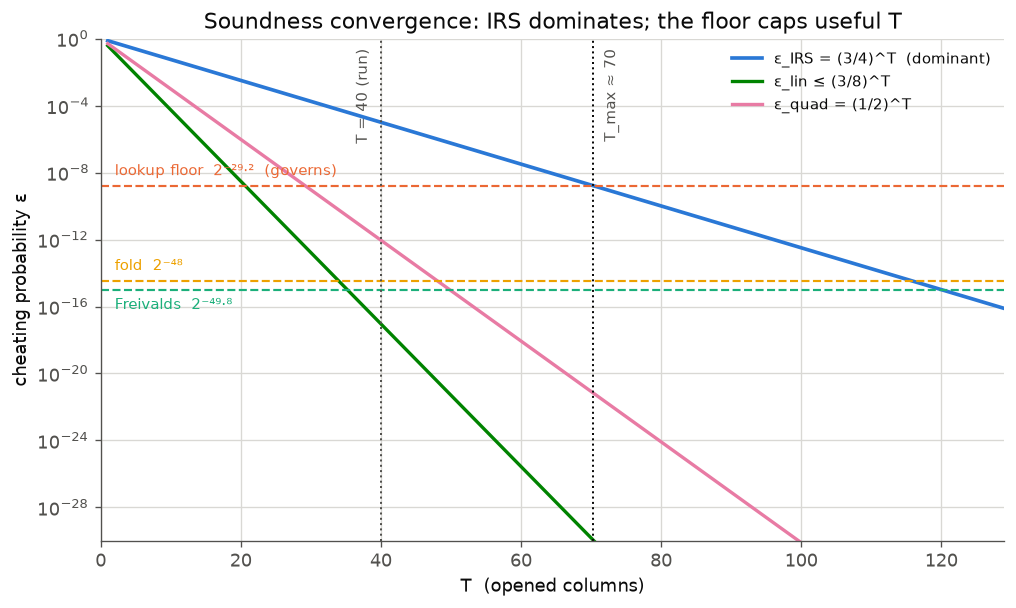

In [9]:
Ts = np.arange(1, 130)
fig, ax = plt.subplots(figsize=(8.6, 5.2))
ax.semilogy(Ts, [eps_irs(4,t) for t in Ts], color=PAL[0], lw=2.2, label="ε_IRS = (3/4)^T  (dominant)")
ax.semilogy(Ts, [eps_lin(RUN['K'],RUN['ELL'],RUN['N'],t) for t in Ts], color=PAL[1], lw=2, label="ε_lin ≤ (3/8)^T")
ax.semilogy(Ts, [eps_quad(RUN['K'],RUN['N'],t) for t in Ts], color=PAL[2], lw=2, label="ε_quad = (1/2)^T")
# Floor lines — labels parked at the far left (x≈2), where all decaying curves are
# still near the top, so the label band 2^-29..2^-50 is empty. Stagger above/below.
ax.axhline(floor["lookup"],    color=PAL[5], ls="--", lw=1.3)
ax.axhline(floor["fold"],      color=PAL[3], ls="--", lw=1.3)
ax.axhline(floor["freivalds"], color=PAL[4], ls="--", lw=1.3)
ax.text(2, floor["lookup"]*2.6,  "lookup floor  2⁻²⁹·²  (governs)", color=PAL[5], fontsize=9, va="bottom")
ax.text(2, floor["fold"]*2.6,    "fold  2⁻⁴⁸",                      color=PAL[3], fontsize=9, va="bottom")
ax.text(2, floor["freivalds"]*0.33, "Freivalds  2⁻⁴⁹·⁸",           color=PAL[4], fontsize=9, va="top")
# Vertical markers — labels near the top (y≈0.25), where the curves are far below.
for xv, lab, ha in [(40, "T = 40 (run)", "right"), (T_max, f"T_max ≈ {T_max:.0f}", "left")]:
    ax.axvline(xv, color=MUTED if lab.startswith("T =") else INK, ls=":", lw=1.2)
    ax.text(xv + (-1.5 if ha=="right" else 1.5), 0.25, lab, rotation=90, va="top", ha=ha, color=MUTED, fontsize=9)
ax.set_xlabel("T  (opened columns)"); ax.set_ylabel("cheating probability ε")
ax.set_title("Soundness convergence: IRS dominates; the floor caps useful T")
ax.set_ylim(1e-30, 1); ax.set_xlim(0, 129)
ax.legend(loc="upper right", frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 5. Cost model and its validation

Each heavy step is a transform (or hash) over a full row, amortized across the
$\text{ELL}$ payload slots — so each per-slot constant carries the factor
$\lambda = K/\text{ELL}$ and a transform cost $c(n)$. The imported model prices
these with the machine's measured $c(n)$ curve.

**What the constants actually validate.** The five per-slot constants are
reconstructed two ways — from a single flat rate $c$, and from the measured
per-length curve — but only one is an independent check. $A_f = 8c$ is the real
test ($3.36$ vs the reference $3.4$). $D = (N/8)h/\text{ELL}$ is a tautology here
because $N/8 = \text{ELL}$, so $D \equiv h = 0.5$. $C$ matches only because $\kappa$
was *calibrated* to make it match. And $A_c$ on the **measured** curve — the curve
the results actually use — is $3.54$, not the reference $4.2$: a real 16% gap,
because $2^{14}$ and $2^{16}$ ride different points of the kernel curve. So the
constants are not a gate; the model's real validation is the end-to-end run below,
and even that agrees only to a factor of ~2 on prover time. The `status` column
says which is which.

In [10]:
K, ELL, rho = 16384, 8192, 4; N = rho*K
h, kappa = lpd.HASH_NS_PER_COMPRESSION, lpd.QUAD_TRANSFORMS_PER_ROW
def constants(cfun):
    return [(K*cfun(K)+N*cfun(N))/ELL, (K*cfun(K)+N*cfun(N))/ELL,
            4*K*cfun(2*K)/ELL, (N/8)*h/ELL, kappa*(2*K)*cfun(2*K)/ELL]
const_tbl = pd.DataFrame({
    "constant": ["A_c commit-encode","A_x column re-encode","A_f linear fold","D hashing","C quadratic fold"],
    "reference": [4.2, 4.2, 3.4, 0.5, 15.0],
    "flat rate c": constants(lambda n: RUN["c_ref"]),
    "measured curve (used in results)": constants(lpd.c),
    "status": ["curve-dependent: 3.54 vs 4.2 (16% off), NOT gated",
               "identical expression to A_c (duplicate)",
               "the one independent check: 8c = 3.36 vs 3.4",
               "tautology: N/8 = ELL ⇒ D ≡ h",
               "circular: κ calibrated to hit 15"],
}).set_index("constant")
# The only genuine, non-circular check:
assert abs(4*K*lpd.c(2*K)/ELL - 3.4) < 0.1, "A_f (the one independent constant) must land near 3.4"
const_tbl

,reference,flat rate c,measured curve (used in results),status
constant,,,,
A_c commit-encode,4.2,4.2,3.543,"curve-dependent: 3.54 vs 4.2 (16% off), NOT gated"
A_x column re-encode,4.2,4.2,3.543,identical expression to A_c (duplicate)
A_f linear fold,3.4,3.36,3.36,the one independent check: 8c = 3.36 vs 3.4
D hashing,0.5,0.5,0.5,tautology: N/8 = ELL ⇒ D ≡ h
C quadratic fold,15,14.95,14.95,circular: κ calibrated to hit 15


The end-to-end reproduction. Note prover time: the model gives the identity
**floor** (8.0 h), but the run measured **19.3 h** — the identity omits fold memory
traffic and orchestration, so it is optimistic by ~2.4×. Any dollar figure built on
the model's prove time (Section 7) inherits that ~2× optimism.

In [11]:
r40 = lpd.cost(16384, 8192, 8192, 4, T=40)
run_repro = pd.DataFrame([
    dict(quantity="prove time",      model=f"{r40['prove_h']:.1f} h (floor)",
         measured="19.3 h", ratio=f"{19.3/r40['prove_h']:.1f}× over floor"),
    dict(quantity="proof (binary)",  model=f"{r40['proof_gb']:.1f} GB",  measured="36.9 GB", ratio="≈1×"),
    dict(quantity="proof (as JSON)", model=f"{r40['proof_json_gb']:.0f} GB", measured="92 GB", ratio="≈1×"),
    dict(quantity="verify time",     model=f"{r40['verify_h']:.1f} h",
         measured="17.7 h @ T=40", ratio="≈1×"),
    dict(quantity="matrix rows",     model=f"{r40['rows']:.3e}", measured="1.152e8", ratio="≈1×"),
]).set_index("quantity")
run_repro

,model,measured,ratio
quantity,,,
prove time,8.0 h (floor),19.3 h,2.4× over floor
proof (binary),36.9 GB,36.9 GB,≈1×
proof (as JSON),93 GB,92 GB,≈1×
verify time,18.7 h,17.7 h @ T=40,≈1×
matrix rows,1.152e+08,1.152e8,≈1×


## 6. Finding the optima

### 6.1  Proof size vs `K`

Proof size is $P(K) \approx 8TW/K + 32K$: the opened columns fall with $K$, the
test polynomials grow. They cross at $K^\ast = \tfrac12\sqrt{TW}$. The reachable
ceiling, though, is not that analytic minimum but the **padding loss** — witness
variables shorter than a row leave unused remainder, which grows with $K$.

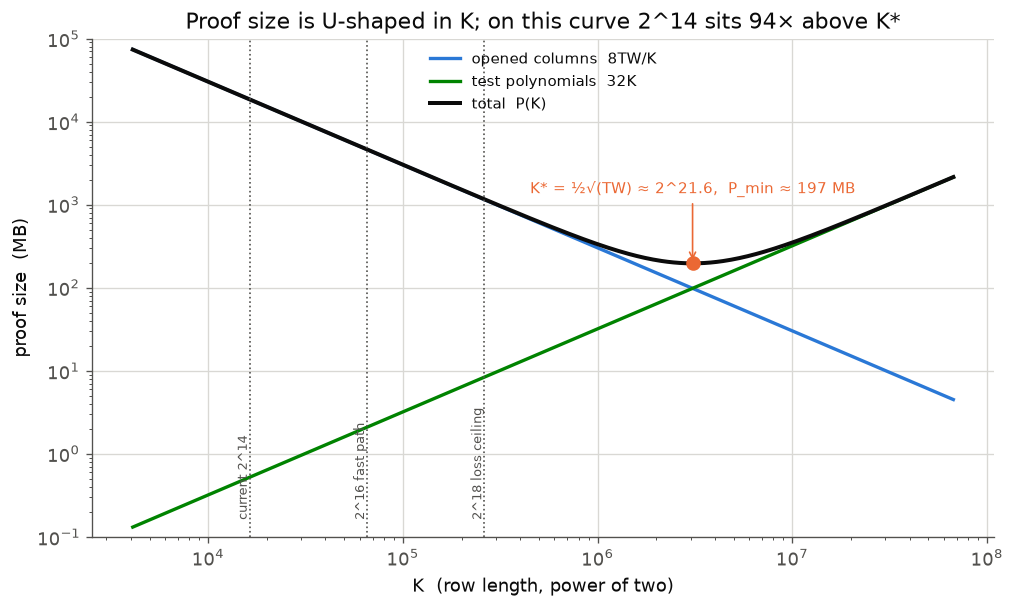

,proof (MB),× vs 2^14,padding loss
K,,,
2^14 (current),1.844e+04,1,0.05%
2^16,"4,611",3.998,0.22%
2^18 (loss ceiling),"1,161",15.88,0.87%
K* ≈ 2^21.6,196.6,93.77,10.25%


In [12]:
def P_of_K(K, T, W):  return 8*T*W/K + 32*K
def K_star(T, W):     return 0.5*math.sqrt(T*W)
def padding_loss(n_vars, ELL, W): return n_vars*ELL/(2*W)

Ks = np.logspace(12, 26, 400, base=2)
Kopt, Pmin = K_star(RUN["T"], RUN["W"]), 32*math.sqrt(RUN["T"]*RUN["W"])
fig, ax = plt.subplots(figsize=(8.6, 5.2))
ax.loglog(Ks, 8*RUN["T"]*RUN["W"]/Ks/1e6, color=PAL[0], lw=2, label="opened columns  8TW/K")
ax.loglog(Ks, 32*Ks/1e6, color=PAL[1], lw=2, label="test polynomials  32K")
ax.loglog(Ks, P_of_K(Ks,RUN["T"],RUN["W"])/1e6, color=INK, lw=2.4, label="total  P(K)")
ax.scatter([Kopt],[Pmin/1e6], color=PAL[5], zorder=6, s=60)
# Annotation parked straight above the minimum (empty band between the min and the
# rising arms); vertical guide labels parked at the bottom (empty).
ax.annotate(f"K* = ½√(TW) ≈ 2^{math.log2(Kopt):.1f},  P_min ≈ {Pmin/1e6:.0f} MB",
            xy=(Kopt, Pmin/1e6), xytext=(Kopt, Pmin/1e6*7),
            ha="center", fontsize=9, color=PAL[5],
            arrowprops=dict(arrowstyle="->", color=PAL[5], lw=1))
for Kv, lab in [(2**14,"current 2^14"),(2**16,"2^16 fast path"),(2**18,"2^18 loss ceiling")]:
    ax.axvline(Kv, color=MUTED, ls=":", lw=1.0)
    ax.text(Kv, 0.16, lab, rotation=90, color=MUTED, fontsize=8, va="bottom", ha="right")
ax.set_xlabel("K  (row length, power of two)"); ax.set_ylabel("proof size  (MB)")
ax.set_ylim(0.1, 1e5)
ratio_graph = P_of_K(2**14,RUN["T"],RUN["W"])/Pmin
ax.set_title(f"Proof size is U-shaped in K; on this curve 2^14 sits {ratio_graph:.0f}× above K*")
ax.legend(frameon=False, fontsize=9, loc="upper center"); plt.tight_layout(); plt.show()

# This curve holds ELL ≈ K (λ=1) on both ends. The often-quoted ~190× compares a
# different pair: the as-is proof at λ=2 (36.9 GB) against P_min at λ=1 — two
# configs, not a move along one curve. Within the 2^18 loss ceiling the gain is far
# smaller; the table makes both the size and the reachable-loss story explicit.
kcmp = pd.DataFrame({"K":["2^14 (current)","2^16","2^18 (loss ceiling)","K* ≈ 2^21.6"],
    "proof (MB)":[P_of_K(kk,RUN["T"],RUN["W"])/1e6 for kk in (2**14,2**16,2**18,int(Kopt))],
    "× vs 2^14":[P_of_K(2**14,RUN["T"],RUN["W"])/P_of_K(kk,RUN["T"],RUN["W"]) for kk in (2**14,2**16,2**18,int(Kopt))],
    "padding loss":[f"{padding_loss(6.3e4,kk,RUN['W'])*100:.2f}%" for kk in (2**14,2**16,2**18,int(Kopt))]})
kcmp.set_index("K")

### 6.2  The prover-side price of `K`: the NTT curve `c(n)`

Larger `K` costs the prover through `c(n)` (ns/element of the NTT). The measured
curve dips at `2^16` — a 4-step fast path exists only there; every other length is
on the generic path where memory passes grow. Implementing the fast path at all
lengths flattens the curve and removes the trade-off.

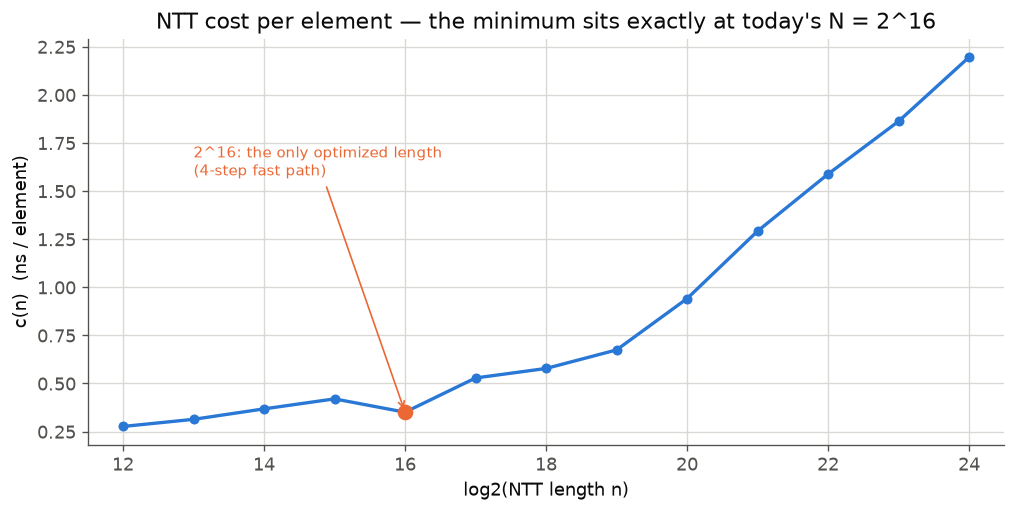

log2 n,12,13,14,15,16,17,18,19,20,21,22,23,24
c(n) ns/elem,0.277,0.314,0.368,0.42,0.351,0.529,0.578,0.674,0.941,1.292,1.589,1.863,2.196


In [13]:
lgs = list(range(12,25)); cn = [lpd.c(2**l) for l in lgs]
fig, ax = plt.subplots(figsize=(8.6,4.4))
ax.plot(lgs, cn, color=PAL[0], lw=2, marker="o", ms=5)
ax.scatter([16],[lpd.c(2**16)], color=PAL[5], zorder=6, s=70)
# Annotation parked in the empty upper-left region, arrow down to the dip.
ax.annotate("2^16: the only optimized length\n(4-step fast path)",
            xy=(16, lpd.c(2**16)), xytext=(13.0, max(cn)*0.72),
            fontsize=9, color=PAL[5], arrowprops=dict(arrowstyle="->", color=PAL[5], lw=1))
ax.set_xlabel("log2(NTT length n)"); ax.set_ylabel("c(n)  (ns / element)")
ax.set_xlim(11.5, 24.5)
ax.set_title("NTT cost per element — the minimum sits exactly at today's N = 2^16")
plt.tight_layout(); plt.show()
pd.DataFrame({"log2 n":lgs, "c(n) ns/elem":[round(x,3) for x in cn]}).set_index("log2 n").T

### 6.3  `ρ` — the choice is forced by cost, not by an impossibility

`ρ = 2` is often described as "never catches," but the exact quadratic miss is
`(2K−2)/N = 1 − 1/K`, not 1 — it catches with probability `1/K` per column. The
honest consequence is that the per-column soundness at `ρ = 2` is `≈ 1/(K ln2)`
bits, so reaching 16.6 bits needs ~188,000 columns: impractical, not impossible.
The dominant miss at each `ρ` is `max(IRS, quad_exact)`; the table computes `T`
from that — no hardcoded `inf`. At `ρ = 2` the quadratic term dominates and blows
up `T`; at `ρ ≥ 4` IRS dominates. `ρ = 8` lowers `T` but ~doubles per-row
encode/hash, and the prover is the bottleneck — so `ρ = 4`.

In [14]:
def dominant_miss(K, N, rho): return max(miss_irs(rho), miss_quad_exact(K, N))
def T_honest(K, N, rho, bits=16.6): return bits / -math.log2(dominant_miss(K, N, rho))

rho_tbl = pd.DataFrame([
    dict(rho=r, N_over_K=r, miss_irs=miss_irs(r), miss_quad_exact=miss_quad_exact(RUN["K"], r*RUN["K"]),
         dominant=dominant_miss(RUN["K"], r*RUN["K"], r),
         bits_per_col=-math.log2(dominant_miss(RUN["K"], r*RUN["K"], r)),
         T_for_16_6=round(T_honest(RUN["K"], r*RUN["K"], r)),
         encode_cost_rel=r/4)
    for r in (2,4,8)]).set_index("rho")
assert rho_tbl.loc[2,"T_for_16_6"] > 100000 and rho_tbl.loc[4,"T_for_16_6"] == 40
rho_tbl

,N_over_K,miss_irs,miss_quad_exact,dominant,bits_per_col,T_for_16_6,encode_cost_rel
rho,,,,,,,
2,2,0.8333,0.9999,0.9999,8.806e-05,188513,0.5
4,4,0.75,0.5,0.75,0.415,40,1
8,8,0.7083,0.25,0.7083,0.4975,33,2


### 6.4  `pad` / `λ`, and the recommit economics

`λ = K/(K − pad)` multiplies prover, proof, and verifier. Only the persistent
weight commitment needs a long masking lifetime (`pad ≥ T·Q_c`, `Q_c` = proofs per
commit); per-proof activation blocks recommit every proof and need only `pad = T`.
A single global `pad` forces the weight block's `λ` onto the activations. The
weight block's `pad` trades `λ` against the amortized cost of re-encoding the
commitment, shown in the last column.

In [15]:
T = RUN["T"]; K = 2**14
enc_row_ns = K*lpd.c(K) + (rho*K)*lpd.c(rho*K)           # one commit-encode per weight row
pad_tbl = pd.DataFrame({"pad":[8192,1024,256,40]})
pad_tbl["ELL = K−pad"] = K - pad_tbl["pad"]
pad_tbl["lambda"]      = K / (K - pad_tbl["pad"])
pad_tbl["Q_c = pad/T"] = (pad_tbl["pad"]/T).round().astype(int)
rows_weight = RUN["W_weights"] / pad_tbl["ELL = K−pad"]
recommit_s  = rows_weight * enc_row_ns / 1e9 / pad_tbl["Q_c = pad/T"]
pad_tbl["recommit / proof"] = recommit_s.map(lambda x: f"{x:.0f} s" if x < 90 else f"{x/60:.0f} min")
pad_tbl.set_index("pad")

,ELL = K−pad,lambda,Q_c = pad/T,recommit / proof
pad,,,,
8192,8192,2,205,7 s
1024,15360,1.067,26,29 s
256,16128,1.016,6,2 min
40,16344,1.002,1,12 min


### 6.5  Recovering `n_vars` from two measured loss points

The padding loss $\approx n_{\text{vars}}\cdot\text{ELL}/(2W)$ is the only place
$n_{\text{vars}}$ (the number of witness variables) enters. Two measured loss
points — ~0.2% at $K=2^{16}$ and ~7% at $K=2^{21}$ — both back out the same
$n_{\text{vars}} \approx 6\times10^{4}$, which then predicts the whole loss curve
and the practical `K` ceiling near $2^{18}$.

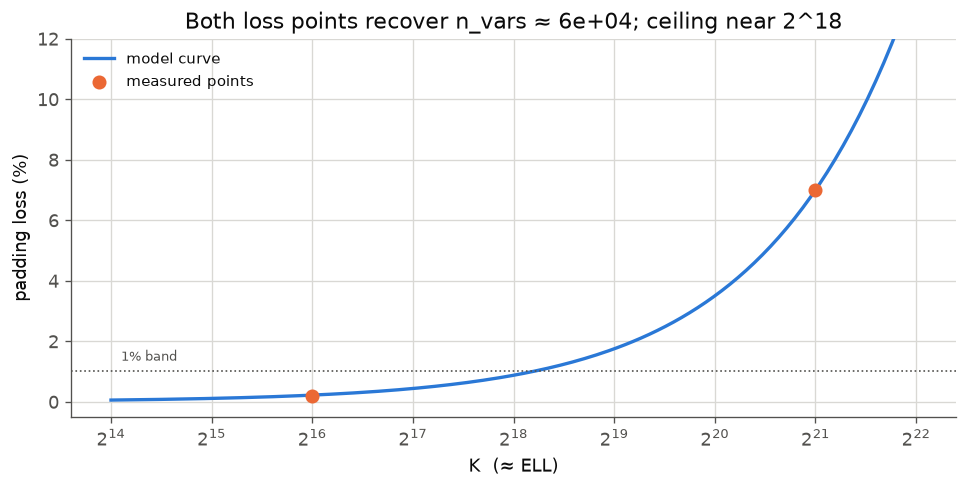

,ELL,measured_loss,n_vars
K,,,
2^16,65536,0.2%,5.762e+04
2^21,2097152,7%,6.302e+04


In [16]:
def nvars_from_loss(loss, ELL, W): return loss * 2*W / ELL
nv = pd.DataFrame([
    dict(K="2^16", ELL=2**16, measured_loss="0.2%", n_vars=nvars_from_loss(0.002, 2**16, RUN["W"])),
    dict(K="2^21", ELL=2**21, measured_loss="7%",   n_vars=nvars_from_loss(0.07,  2**21, RUN["W"])),
]).set_index("K")
n_vars = 6.3e4
fig, ax = plt.subplots(figsize=(8.2,4.2))
Kp = np.logspace(14,22,200,base=2)
ax.semilogx(Kp, padding_loss(n_vars, Kp, RUN["W"])*100, color=PAL[0], lw=2, base=2, label="model curve")
ax.scatter([2**16,2**21],[0.2,7.0], color=PAL[5], zorder=6, s=55, label="measured points")
ax.axhline(1.0, color=MUTED, ls=":", lw=1)
ax.text(2**14.1, 1.25, "1% band", color=MUTED, fontsize=8, va="bottom")
ax.set_xlabel("K  (≈ ELL)"); ax.set_ylabel("padding loss (%)"); ax.set_ylim(-0.5, 12)
ax.set_title(f"Both loss points recover n_vars ≈ {n_vars:.0e}; ceiling near 2^18")
ax.legend(frameon=False, fontsize=9, loc="upper left"); plt.tight_layout(); plt.show()
nv

## 7. The configuration spectrum, from one cost model

One named `Config`, one `price()` that every table and plot below calls -- so the same
configuration always yields the same numbers. This replaces an earlier flat-kernel
spectrum: `c(n)` (NTT ns/element) is L2/DRAM-bound and never flat, so the only real
kernel lever is the **coset-NTT** used below (encode as `rho` length-`K` transforms
instead of one length-`rho*K`), not an imagined flat kernel.

**Dependency network** (change any field of `Config`; everything downstream moves):

```
S ─────────────────────────► W(S), Q(S), L(S)  and  M(S) (LogUp accesses)
M, field_bits, logup_repeats, rho, K ─► eps_floor ─► soundness ceiling   (the hub)
T_queries, rho ────────────► delivered soundness    (paid in proof & verify, NOT prover)
S, K, rho, pad, coset_ntt, witness_passes ─► prover time (named terms)
T_queries, K, pad, S ──────► proof size, verifier time
```

**Two modelling choices, stated once.** (i) Witness sizes come from the closed forms
`lpd.W_of(S)` etc. -- the canonical source, within ~1% of the measured 9.44e11 at S=1093.
(ii) All times are the *identity floor*; measured wall-clock is ~1.5-2.4x (`paper.md` A.5).
The transform terms are memory-bandwidth bound, so the only lever on them is *fewer*
transforms -- what `coset_ntt` and a smaller `rho` buy.

In [17]:
from dataclasses import dataclass, replace

@dataclass(frozen=True)
class Config:
    """One proof configuration. Field defaults reproduce the demonstrated 400B run
    (Llama-4-Maverick, 1093 tokens hidden). Change any field; `price()` reprices all."""
    S: int              = RUN["S"]     # context length, tokens -> witness sizes W(S),Q(S),L(S)
    K: int              = RUN["K"]     # row length (power of two)
    rho: int            = RUN["rho"]   # RS inverse rate; codeword length N = rho*K
    pad_weights: int    = RUN["pad"]   # ZK mask slots/row, persistent weight block
    pad_proof: int      = RUN["pad"]   # ZK mask slots/row, per-proof blocks
    T_queries: int      = RUN["T"]     # opened columns (the soundness dial)
    field_bits: int     = 64           # |F| in bits; 128 = degree-2 Goldilocks extension
    logup_repeats: int  = 1            # parallel repetition of the LogUp challenge (floor -> ^n)
    coset_ntt: bool     = False        # encode via rho length-K coset-NTTs vs one length-rho*K
    witness_passes: int = 4            # forward-pass recomputes (4 rounds; 1 w/ claim-streaming)

    @property
    def N(self):           return self.rho * self.K
    @property
    def ELL_weights(self): return self.K - self.pad_weights   # payload slots, weight rows
    @property
    def ELL_proof(self):   return self.K - self.pad_proof     # payload slots, per-proof rows

In [18]:
def price(cfg: Config) -> dict:
    """Everything about one Config: prover time (split into named terms), proof size,
    verifier time, and soundness. Witness sizes are the closed forms in S. Every machine
    constant is read from lpd (measured) -- nothing re-hardcoded here."""
    # --- witness sizes: the one canonical source ---
    W, Q, L   = lpd.W_of(cfg.S), lpd.Q_of(cfg.S), lpd.L_of(cfg.S)
    W_weights = lpd.W_WEIGHTS                 # persistent weight block (S-independent)
    W_proof   = W - W_weights                 # per-proof activations + auxiliaries

    # --- NTT ns/element: measured kernel, or coset-NTT (no encode transform exceeds K) ---
    c = (lambda n: lpd.c(min(n, cfg.K))) if cfg.coset_ntt else lpd.c

    rows_weights = W_weights / cfg.ELL_weights
    rows_proof   = W_proof   / cfg.ELL_proof
    rows         = rows_weights + rows_proof

    # --- prover: per-row transform + hash costs in ns (paper A.5) ---
    def row_ns(commit_encode):
        encode   = cfg.K*c(cfg.K) + cfg.N*c(cfg.N)          # A_c: iNTT_K + forward NTT_N
        reencode = encode                                   # A_x: round-4 column opening
        fold     = 4*cfg.K*c(2*cfg.K)                       # A_f: linear fold (length 2K)
        hashing  = (cfg.N/8)*lpd.HASH_NS_PER_COMPRESSION    # D:  BLAKE3, 8 elements/compress
        return (encode if commit_encode else 0) + reencode + fold + hashing

    weight_lifetime = max(1, cfg.pad_weights // cfg.T_queries)   # weight-commit ZK lifetime
    encode_weight   = cfg.K*c(cfg.K) + cfg.N*c(cfg.N)
    streaming_ns = (rows_proof   * row_ns(commit_encode=True)
                    + rows_weights * (row_ns(commit_encode=False) + encode_weight/weight_lifetime))
    quad_ns = (Q/cfg.ELL_proof) * lpd.QUAD_TRANSFORMS_PER_ROW * (2*cfg.K) * c(2*cfg.K)
    lin_ns  = lpd.B_NS_PER_CID * L

    hours = lambda ns: ns / 1e9 / 3600 / (1 - lpd.E_FRACTION)   # +E: fold-coefficient arithmetic
    prover = dict(
        witness_recompute = cfg.witness_passes * lpd.T_WIT_S/3600 / (1 - lpd.E_FRACTION),
        streaming = hours(streaming_ns),
        quadratic = hours(quad_ns),
        linear    = hours(lin_ns),
    )

    # --- proof size and verifier work (geometry only, kernel-independent) ---
    proof_bytes = cfg.T_queries*rows*lpd.FIELD_BYTES + (4*cfg.K + cfg.ELL_proof)*lpd.FIELD_BYTES
    verify_h    = cfg.T_queries*rows*lpd.VERIFY_NS_PER_CELL/1e9/3600

    # --- soundness: falling column term (3/4)^T against the cheating-probability floor ---
    field     = F * 2.0**(cfg.field_bits - 64)               # |F|, 64-bit or extension
    M         = sum(lookup_M(cfg.S).values())                # LogUp table accesses
    eps_floor = (M/field)**cfg.logup_repeats + (cfg.N+3)/field + RUN["n_mm"]*2/field
    eps       = miss_irs(cfg.rho)**cfg.T_queries + eps_floor

    return dict(W=W, rows=rows,
                prove_h=sum(prover.values()), prover_terms=prover,
                proof_GB=proof_bytes/1e9, verify_h=verify_h,
                soundness_bits=-math.log2(eps),
                soundness_ceiling_bits=-math.log2(eps_floor))

def columns_for_bits(target_bits, rho=RUN["rho"]):
    """Opened columns needed to reach a soundness target (the (3/4)^T term)."""
    return max(1, math.ceil(target_bits / -math.log2(miss_irs(rho))))

# GATE: price(cfg) must equal lpd.cost on identical inputs, and reproduce the demo run.
demo = Config()
_ref = lpd.cost(demo.K, demo.ELL_weights, demo.ELL_proof, demo.rho, demo.T_queries,
                W=lpd.W_of(demo.S), Q=lpd.Q_of(demo.S), L=lpd.L_of(demo.S))
_p = price(demo)
assert abs(_p["prove_h"] - _ref["prove_h"]) < 1e-6
assert abs(_p["proof_GB"] - _ref["proof_gb"]) < 1e-6
assert abs(_p["verify_h"] - _ref["verify_h"]) < 1e-9
print("GATE: price(cfg) == lpd.cost on identical inputs  [OK]")
print(f"demonstrated run -> proof {_p['proof_GB']:.1f} GB, prove {_p['prove_h']:.1f} h floor, "
      f"verify {_p['verify_h']:.1f} h, soundness {_p['soundness_bits']:.1f} bits")
print(" measured 400B run: 36.9 GB / 19.3 h wall (~2.4x floor) / 16.6 bits  -> within ~1%")

GATE: price(cfg) == lpd.cost on identical inputs  [OK]
demonstrated run -> proof 36.6 GB, prove 8.0 h floor, verify 18.5 h, soundness 16.6 bits
 measured 400B run: 36.9 GB / 19.3 h wall (~2.4x floor) / 16.6 bits  -> within ~1%


In [19]:
# ==== THE KNOB ==============================================================
# Edit any field, run this cell, read the whole system. Everything else in the
# section is just this call over pre-set configs. Unset fields keep Config's
# demonstrated-run defaults (S=1093, K=2^14, rho=4, pad=8192, T=40, 4 passes).
cfg = Config(K=2**18, pad_proof=128, coset_ntt=True, T_queries=71)   # <-- turn me
# ===========================================================================

r = price(cfg)
summary = pd.Series({
    "prove_h  (identity floor)":   round(r["prove_h"], 2),
    "prove_h  (~2.4x wall-clock)": round(r["prove_h"] * 2.4, 2),
    "proof_GB":                    round(r["proof_GB"], 2),
    "verify_h":                    round(r["verify_h"], 2),
    "soundness_bits (delivered)":  round(r["soundness_bits"], 1),
    "soundness_ceiling_bits":      round(r["soundness_ceiling_bits"], 1),
    "matrix rows":                 f"{r['rows']:.3e}",
    "lambda_weights = K/ELL_w":    round(cfg.K / cfg.ELL_weights, 3),
    "lambda_proof   = K/ELL_p":    round(cfg.K / cfg.ELL_proof, 3),
}, name="value")
prover_terms = pd.Series({k: round(v, 2) for k, v in r["prover_terms"].items()},
                         name="prove_h by term")
display(summary.to_frame(), prover_terms.to_frame())

,value
prove_h (identity floor),7.09
prove_h (~2.4x wall-clock),17.02
proof_GB,2.07
verify_h,1.04
soundness_bits (delivered),28.3
soundness_ceiling_bits,29.2
matrix rows,3.628e+06
lambda_weights = K/ELL_w,1.032
lambda_proof = K/ELL_p,1


,prove_h by term
witness_recompute,4.52
streaming,1.96
quadratic,0.57
linear,0.03


In [20]:
# Design spectrum: the payoff across configurations, each priced by the one `price()`.
# Honesty flags: prove_h is the identity FLOOR (measured ~2.4x higher, A.5), and it
# feeds usd_per_proof, so the dollar figure is a lower bound, not a quote. soundness_bits
# is the DELIVERED value (falling term + floor), not the IRS-only target.
RATE_USD_PER_GPU_H      = 2.10
PROVE_FLOOR_TO_MEASURED = 2.4

def spectrum_row(label, cfg):
    r = price(cfg)
    usd = RATE_USD_PER_GPU_H * (r["prove_h"] * PROVE_FLOOR_TO_MEASURED + r["verify_h"])
    return dict(configuration=label, T=cfg.T_queries, soundness_bits=round(r["soundness_bits"], 1),
                prove_h_floor=round(r["prove_h"], 1), proof_GB=round(r["proof_GB"], 2),
                verify_h=round(r["verify_h"], 2), usd_per_proof=round(usd))

spectrum = pd.DataFrame([
    spectrum_row("as-is  (K=2^14, pad=8192)",           demo),
    spectrum_row("per-block pad  (K=2^14, pad=128)",     replace(demo, pad_proof=128)),
    spectrum_row("K=2^16, coset-NTT",                    replace(demo, K=2**16, pad_proof=128, coset_ntt=True)),
    spectrum_row("K=2^18, coset-NTT  <- recommend",      replace(demo, K=2**18, pad_proof=128, T_queries=71, coset_ntt=True)),
    spectrum_row("K=2^21, coset-NTT  (regresses)",       replace(demo, K=2**21, pad_proof=128, T_queries=71, coset_ntt=True)),
]).set_index("configuration")
spectrum

,T,soundness_bits,prove_h_floor,proof_GB,verify_h,usd_per_proof
configuration,,,,,,
"as-is (K=2^14, pad=8192)",40,16.6,8,36.63,18.54,79
"per-block pad (K=2^14, pad=128)",40,16.6,6.7,26.21,13.27,62
"K=2^16, coset-NTT",40,16.6,6.2,4.87,2.46,36
"K=2^18, coset-NTT <- recommend",71,28.3,7.1,2.07,1.04,38
"K=2^21, coset-NTT (regresses)",71,28.3,10.1,0.34,0.13,51


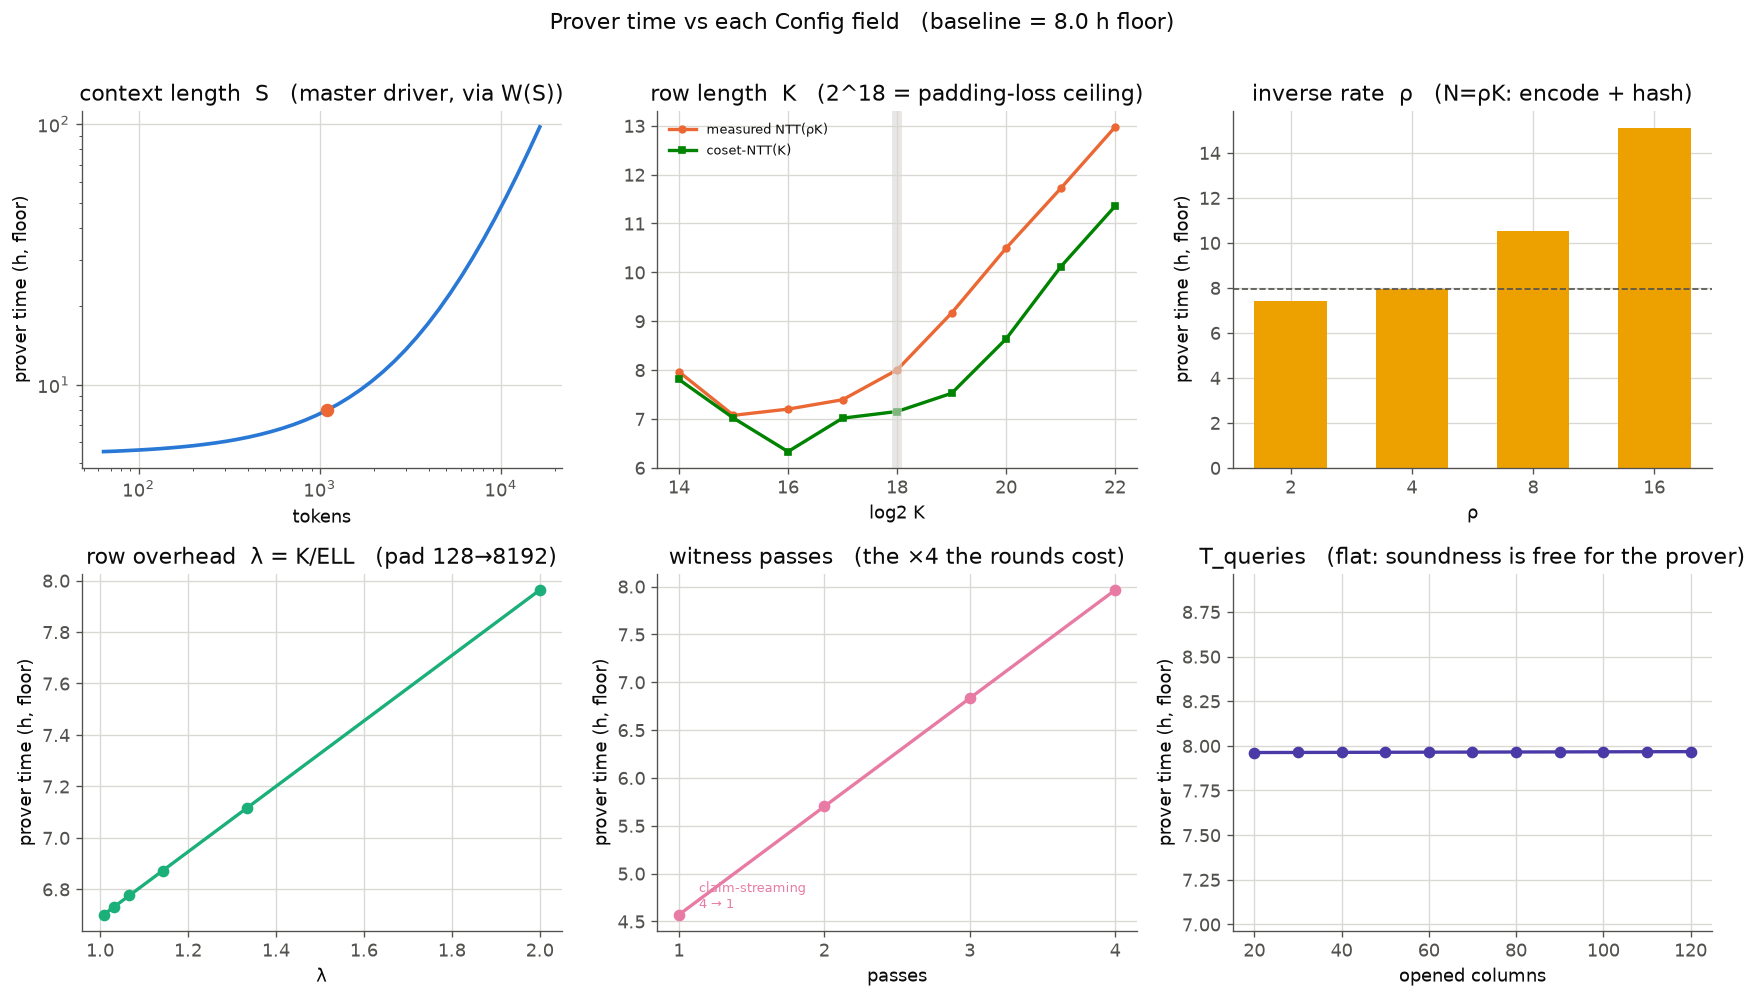

In [21]:
# Prover time vs each Config field -- all six panels call the one `price()`.
def prove(**override): return price(replace(demo, **override))["prove_h"]
BASE = prove()
fig, ax = plt.subplots(2, 3, figsize=(14.5, 8.2))

Ss = np.logspace(math.log2(64), math.log2(16384), 40, base=2)
ax[0,0].loglog(Ss, [prove(S=int(s)) for s in Ss], color=PAL[0], lw=2.2)
ax[0,0].scatter([RUN["S"]], [BASE], color=PAL[5], zorder=6, s=50)
ax[0,0].set_title("context length  S   (master driver, via W(S))")
ax[0,0].set_xlabel("tokens"); ax[0,0].set_ylabel("prover time (h, floor)")

lgK = list(range(14, 23))
ax[0,1].plot(lgK, [prove(K=1<<l) for l in lgK], color=PAL[5], lw=2, marker="o", ms=4, label="measured NTT(ρK)")
ax[0,1].plot(lgK, [prove(K=1<<l, coset_ntt=True) for l in lgK], color=PAL[1], lw=2, marker="s", ms=4, label="coset-NTT(K)")
ax[0,1].axvline(18, color=GRID, lw=6, alpha=.6)
ax[0,1].set_title("row length  K   (2^18 = padding-loss ceiling)")
ax[0,1].set_xlabel("log2 K"); ax[0,1].legend(fontsize=8, frameon=False)

rhos = [2, 4, 8, 16]
ax[0,2].bar([str(r) for r in rhos], [prove(rho=r) for r in rhos], color=PAL[3], width=.6)
ax[0,2].axhline(BASE, color=MUTED, ls="--", lw=1)
ax[0,2].set_title("inverse rate  ρ   (N=ρK: encode + hash)")
ax[0,2].set_xlabel("ρ"); ax[0,2].set_ylabel("prover time (h, floor)")

pads = [128, 512, 1024, 2048, 4096, 8192]
ax[1,0].plot([RUN["K"]/(RUN["K"]-p) for p in pads], [prove(pad_proof=p) for p in pads],
             color=PAL[4], lw=2, marker="o")
ax[1,0].set_title("row overhead  λ = K/ELL   (pad 128→8192)")
ax[1,0].set_xlabel("λ"); ax[1,0].set_ylabel("prover time (h, floor)")

passes = [1, 2, 3, 4]
ax[1,1].plot(passes, [prove(witness_passes=n) for n in passes], color=PAL[2], lw=2, marker="o")
ax[1,1].annotate("claim-streaming\n4 → 1", (1, prove(witness_passes=1)),
                 textcoords="offset points", xytext=(12, 4), fontsize=8, color=PAL[2])
ax[1,1].set_title("witness passes   (the ×4 the rounds cost)")
ax[1,1].set_xlabel("passes"); ax[1,1].set_xticks(passes); ax[1,1].set_ylabel("prover time (h, floor)")

Ts = list(range(20, 121, 10))
ax[1,2].plot(Ts, [prove(T_queries=t) for t in Ts], color=PAL[6], lw=2, marker="o")
ax[1,2].set_ylim(BASE-1, BASE+1)
ax[1,2].set_title("T_queries   (flat: soundness is free for the prover)")
ax[1,2].set_xlabel("opened columns"); ax[1,2].set_ylabel("prover time (h, floor)")

fig.suptitle(f"Prover time vs each Config field   (baseline = {BASE:.1f} h floor)", y=1.01)
plt.tight_layout(); plt.show()

,ceiling_bits,T,proof_GB,verify_h,prove_h
scenario,,,,,
baseline |F|=2^64,29.2,71,65,32.9,8
LogUp repeated (M/|F|)²,47.6,115,105.3,53.3,8
degree-2 extension |F|=2^128,93.2,225,206.1,104.3,8


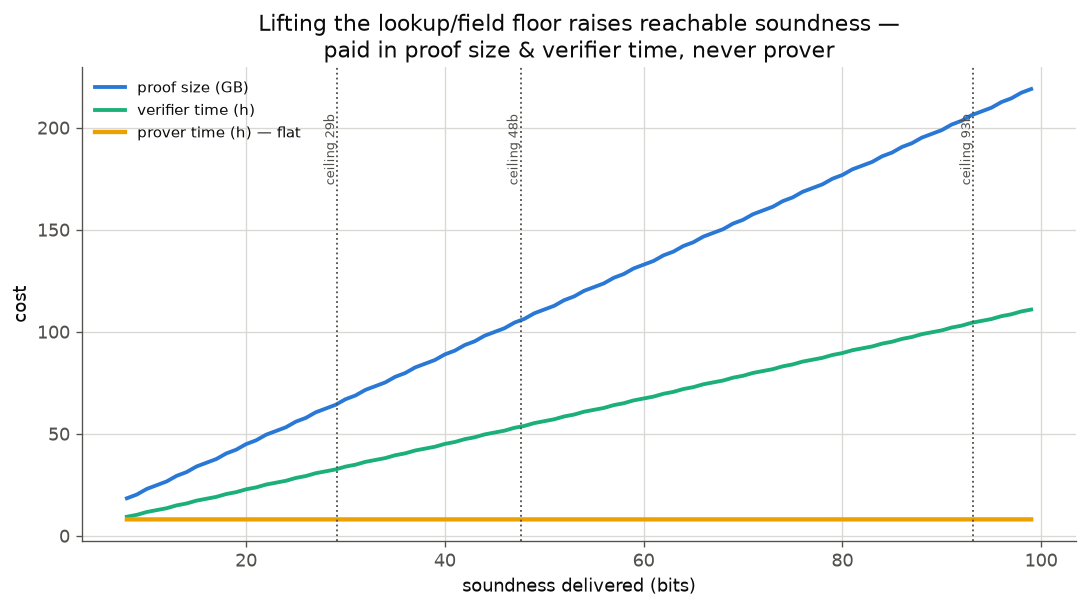

In [22]:
# The coupled trade: lift the lookup/field floor and read the WHOLE system at once.
# Each scenario spends soundness up to its own ceiling.
floor_scenarios = {
    "baseline  |F|=2^64":           Config(),
    "LogUp repeated  (M/|F|)²":     replace(demo, logup_repeats=2),
    "degree-2 extension  |F|=2^128": replace(demo, field_bits=128),
}
rows = []
for label, base_cfg in floor_scenarios.items():
    ceiling = price(base_cfg)["soundness_ceiling_bits"]
    cfg = replace(base_cfg, T_queries=columns_for_bits(ceiling))   # spend up to the ceiling
    r = price(cfg)
    rows.append(dict(scenario=label, ceiling_bits=round(ceiling, 1), T=cfg.T_queries,
                     proof_GB=round(r["proof_GB"], 1), verify_h=round(r["verify_h"], 1),
                     prove_h=round(r["prove_h"], 1)))
display(pd.DataFrame(rows).set_index("scenario"))

fig, ax = plt.subplots(figsize=(9.2, 5.2))
bits = np.arange(8, 100, 1.0)
spend = lambda b: price(replace(demo, T_queries=columns_for_bits(b)))
ax.plot(bits, [spend(b)["proof_GB"] for b in bits], color=PAL[0], lw=2.3, label="proof size (GB)")
ax.plot(bits, [spend(b)["verify_h"] for b in bits], color=PAL[4], lw=2.3, label="verifier time (h)")
ax.plot(bits, [spend(b)["prove_h"]  for b in bits], color=PAL[3], lw=2.6, label="prover time (h) — flat")
for label, base_cfg in floor_scenarios.items():
    cb = price(base_cfg)["soundness_ceiling_bits"]
    ax.axvline(cb, color=MUTED, ls=":", lw=1.1)
    ax.text(cb, ax.get_ylim()[1]*0.9, f" ceiling {cb:.0f}b", color=MUTED, fontsize=8,
            rotation=90, va="top", ha="right")
ax.set_xlabel("soundness delivered (bits)"); ax.set_ylabel("cost")
ax.set_title("Lifting the lookup/field floor raises reachable soundness —\n"
             "paid in proof size & verifier time, never prover")
ax.legend(frameon=False, fontsize=9, loc="upper left"); plt.tight_layout(); plt.show()

threshold 16.6 bits (baseline floor ceiling 29.2) -> optimum by wall-clock:
   K=2^16, rho=4, coset-NTT, T=40  ->  prove 6.2h + verify 2.5h = 17.3h wall  (8.6h floor)


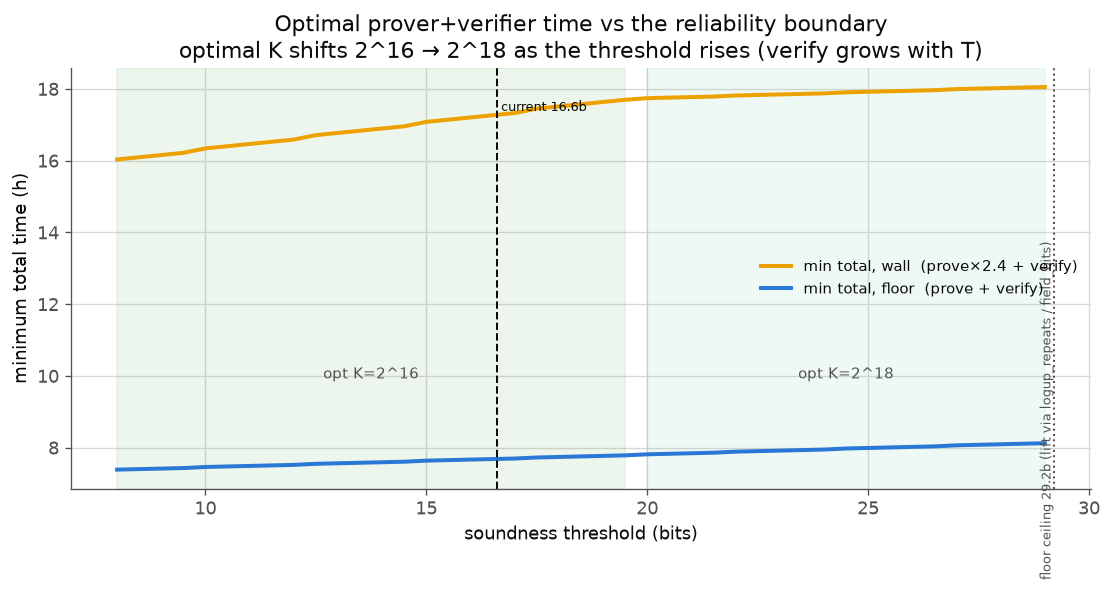

In [23]:
# Minimize total time (prover + verifier) as a function of the SOUNDNESS THRESHOLD.
TARGET_BITS = 16.6      # <-- turn the reliability boundary (bits). Baseline floor caps ~29.

def best_config(target_bits, metric="wall"):
    """Cheapest (K, coset-NTT) at a soundness threshold; rho=4, per-block pad.
    metric='wall' counts the prover at ~2.4x (A.5); 'floor' at the identity floor."""
    best, best_total = None, math.inf
    for lgK in range(14, 19):                       # 2^18 = padding-loss ceiling (6.5)
        cfg = replace(demo, K=1 << lgK, rho=4, pad_weights=8192, pad_proof=128,
                      coset_ntt=True, T_queries=columns_for_bits(target_bits, 4))
        r = price(cfg)
        total = (2.4*r["prove_h"] + r["verify_h"]) if metric == "wall" else (r["prove_h"] + r["verify_h"])
        if total < best_total:
            best, best_total = (lgK, cfg, r), total
    return best, best_total

ceiling = round(price(demo)["soundness_ceiling_bits"], 1)
(lgK, cfg, r), total = best_config(TARGET_BITS, "wall")
print(f"threshold {TARGET_BITS} bits (baseline floor ceiling {ceiling}) -> optimum by wall-clock:")
print(f"   K=2^{lgK}, rho=4, coset-NTT, T={cfg.T_queries}  ->  prove {r['prove_h']:.1f}h + "
      f"verify {r['verify_h']:.1f}h = {total:.1f}h wall  ({r['prove_h']+r['verify_h']:.1f}h floor)")

# How the optimum (time and best K) moves as you crank the boundary.
bits  = np.arange(8, ceiling, 0.5)
wall  = [best_config(b, "wall")[1]     for b in bits]
floor = [best_config(b, "floor")[1]    for b in bits]
optK  = [best_config(b, "wall")[0][0]  for b in bits]

fig, ax = plt.subplots(figsize=(9.4, 5.0))
ax.plot(bits, wall,  color=PAL[3], lw=2.4, label="min total, wall  (prove×2.4 + verify)")
ax.plot(bits, floor, color=PAL[0], lw=2.4, label="min total, floor  (prove + verify)")
for k in sorted(set(optK)):                         # shade where each K is optimal (wall)
    seg = [b for b, kk in zip(bits, optK) if kk == k]
    ax.axvspan(min(seg), max(seg), color=(PAL[1] if k == 16 else PAL[4]), alpha=0.07)
    ax.text((min(seg)+max(seg))/2, max(wall)*0.55, f"opt K=2^{k}", fontsize=9, ha="center", color=MUTED)
ax.axvline(TARGET_BITS, color=INK, ls="--", lw=1.2)
ax.text(TARGET_BITS, max(wall)*0.98, " current 16.6b", fontsize=8, va="top")
ax.axvline(ceiling, color=MUTED, ls=":", lw=1.2)
ax.text(ceiling, max(wall)*0.5, f"floor ceiling {ceiling}b (lift via logup_repeats / field_bits)",
        fontsize=8, va="center", ha="right", rotation=90, color=MUTED)
ax.set_xlabel("soundness threshold (bits)"); ax.set_ylabel("minimum total time (h)")
ax.set_title("Optimal prover+verifier time vs the reliability boundary\n"
             "optimal K shifts 2^16 → 2^18 as the threshold rises (verify grows with T)")
ax.legend(frameon=False, fontsize=9, loc="center right"); plt.tight_layout(); plt.show()

**What the model says** (each line is one `Config`, priced by `price`).

- **Best real design: `Config(K=2**18, pad_proof=128, coset_ntt=True, T_queries=71)`** ->
  ~7 h prover, ~2 GB proof (vs 37), ~1 h verify. `K=2^18` is the padding-loss ceiling
  (6.5); `K=2^21` regresses -- the length-`2K` fold and the witness floor do not shrink.
- **Soundness is the LogUp floor's story.** Baseline caps at ~29 bits; `logup_repeats=2`
  lifts it to ~48, `field_bits=128` to ~93. The coupled figure prices the trade: proof
  and verifier scale with `T`, the prover stays flat -- reliability is spent on proof
  size and verifier time, never prover time.

**Where the prover hours go, and claim-streaming.** At fixed context the floor is the
4x witness recompute plus encode/fold over `W`. The x4 exists because the witness (7.2 TB)
cannot be stored (78 GB GPU) and each of the 4 Fiat-Shamir rounds re-streams it.
`claim-streaming` (9) finishes each claim's rounds while its rows are live -> set
`witness_passes=1` and drop the round-4 re-encode, ~1/3 off the floor. Caveat: `T_wit` is
held at its measured ~1 h/pass (dense-calibrated); the paper's instrumented witness share
is 10-29%, so `witness_passes` overstates the win for the MoE-heavy run.

## 8. Which parameters are critical

A one-at-a-time sweep: move each knob across its feasible range and record the span
it induces in each output. The widest span is the most critical knob for that
output. Note `T` has no interior optimum — it is monotone in every output, so its
span here is just the range of the chosen `T` window (30→71); it is a *policy*
input, not something the analysis solves for. Rows share a fixed order so each knob
is comparable across the four panels.

In [18]:
def outputs(K, pad, rho, T, W=RUN["W"], S=RUN["S"], n_mm=RUN["n_mm"]):
    N = rho*K; ELL = K - pad
    proof = 8*T*W/ELL + 8*(4*K+ELL)
    verify = T * (W/ELL)
    eps = eps_irs(rho,T)+eps_lin(K,ELL,N,T)+eps_quad(K,N,T) + sum(lookup_M(S).values())/F + (N+3)/F + n_mm*2/F
    r = lpd.cost(K, ELL, ELL, rho, T)
    return dict(proof_GB=proof/1e9, verify_rel=verify, prove_h=r["prove_h"], soundness_bits=-math.log2(eps))

base_o = outputs(2**14, 8192, 4, 40)
sweeps = {
    "K   (2^14→2^18)": [outputs(2**l, 8192, 4, 40) for l in (14,16,18)],
    "pad (8192→128)":  [outputs(2**14, p, 4, 40) for p in (8192,1024,128)],
    "T   (30→71)":     [outputs(2**14, 8192, 4, t) for t in (30,40,71)],
    "rho (4→8)":       [outputs(2**14, 8192, r, 40) for r in (4,8)],
}
metrics = ["proof_GB","verify_rel","prove_h","soundness_bits"]
span = lambda vs,m: (max(v[m] for v in vs)-min(v[m] for v in vs))/(abs(base_o[m]) or 1)
sens = pd.DataFrame({k:{m:span(vs,m) for m in metrics} for k,vs in sweeps.items()}).T[metrics]
sens.columns = ["proof size","verify time","prove time","soundness"]
sens.map(lambda x: f"{x*100:.0f}%")

,proof size,verify time,prove time,soundness
K (2^14→2^18),97%,97%,10%,0%
pad (8192→128),50%,50%,20%,0%
T (30→71),102%,102%,0%,96%
rho (4→8),0%,0%,32%,20%


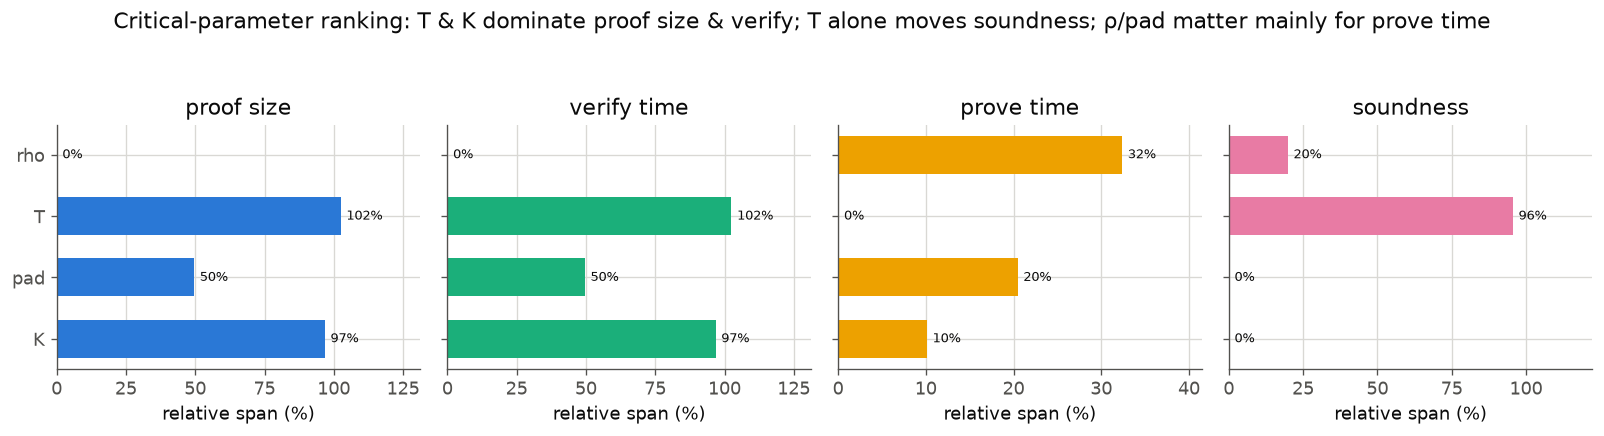

In [19]:
order = list(sweeps); labels = [k.split()[0] for k in order]
titles = ["proof size","verify time","prove time","soundness"]
cols = {"proof size":PAL[0],"verify time":PAL[4],"prove time":PAL[3],"soundness":PAL[2]}
fig, axes = plt.subplots(1, 4, figsize=(13.5, 3.4), sharey=True)
for ax, col in zip(axes, titles):
    vals = [sens.loc[k, col]*100 for k in order]
    ax.barh(range(len(order)), vals, color=cols[col], height=0.62)
    ax.set_yticks(range(len(order))); ax.set_yticklabels(labels)
    ax.set_title(col); ax.set_xlabel("relative span (%)"); ax.set_xlim(0, max(max(vals)*1.28, 5))
    for i,v in enumerate(vals): ax.text(v+max(vals)*0.02, i, f"{v:.0f}%", va="center", fontsize=8, color=INK)
    ax.invert_yaxis()
fig.suptitle("Critical-parameter ranking: T & K dominate proof size & verify; "
             "T alone moves soundness; ρ/pad matter mainly for prove time", y=1.06)
plt.tight_layout(); plt.show()

`T` and `K` dominate proof size and verifier work; `T` is the only knob that moves
soundness (and it moves size too — you cannot buy soundness without paying proof
size). `pad` is a secondary size/verify lever; `ρ` matters mainly for prover time
and is pinned at 4. The fixed-point scale `s` touches none of these — set by
accuracy alone, already optimal — so it is excluded from the sweep.

## 9. Toy-model validation over the Goldilocks field

The whole soundness argument reduces to one field fact: two distinct polynomials of
degree $< D$ over $F$ agree in at most $D-1$ of $N$ points. All three
miss-probability formulas are instances of it. Below it is checked by actual
Goldilocks arithmetic — pure Python integers modulo $p = 2^{64}-2^{32}+1$, no GPU —
on small power-of-two configurations of the same shape the protocol uses. Each
check is an `assert`; the cell fails loudly if the arithmetic disagrees with the
formula.

In [20]:
G = 7
def root_of_unity(n):
    assert (P-1) % n == 0
    w = pow(G, (P-1)//n, P); assert pow(w,n,P)==1 and pow(w,n//2,P)!=1
    return w
def domain(n):     w = root_of_unity(n); return [pow(w,j,P) for j in range(n)]
def poly_eval(c, x):
    acc = 0
    for k in reversed(c): acc = (acc*x + k) % P
    return acc
rng = np.random.default_rng(0)
def rand_field(n): return [int(v) for v in rng.integers(0, P, size=n, dtype=np.uint64)]

# Mirror the protocol's structural constraints on a small config.
ELL0, K0, N0 = 4, 8, 32
assert ELL0<=K0<=N0 and K0&(K0-1)==0 and N0&(N0-1)==0
assert (P-1)%K0==0 and (P-1)%N0==0 and 2*K0<=N0
assert all(pow(root_of_unity(n),n,P)==1 for n in (16,32,64))
cfg_ok = pd.DataFrame([dict(check="ELL≤K≤N", ok=True), dict(check="K,N powers of two", ok=True),
                       dict(check="(p−1) divisible by K,N", ok=True), dict(check="2K≤N (degree gap)", ok=True)]).set_index("check")
cfg_ok

,ok
check,
ELL≤K≤N,True
"K,N powers of two",True
"(p−1) divisible by K,N",True
2K≤N (degree gap),True


### 9.1  Reed–Solomon distance — an error cannot be local

Encode a length-`K` message as a degree-`<K` polynomial evaluated at `N` points.
Changing one message symbol must flip at least `d = N−K+1` codeword positions. The
cell asserts the measured minimum never drops below `d`.

In [21]:
K, N = 8, 32; pts = domain(N); d_theory = N-K+1
worst, hist = N+1, []
for _ in range(3000):
    msg = rand_field(K); cw = [poly_eval(msg,x) for x in pts]
    i = int(rng.integers(0,K)); delta = int(rng.integers(1,P,dtype=np.uint64))
    m2 = msg.copy(); m2[i] = (m2[i]+delta)%P
    diff = sum(a!=b for a,b in zip(cw,[poly_eval(m2,x) for x in pts]))
    hist.append(diff); worst = min(worst, diff)
assert worst >= d_theory
pd.DataFrame([dict(quantity="code distance d = N−K+1", value=d_theory),
              dict(quantity="min positions flipped (measured)", value=worst),
              dict(quantity="mean positions flipped (measured)", value=round(float(np.mean(hist)),1))]).set_index("quantity")

,value
quantity,
code distance d = N−K+1,25
min positions flipped (measured),32
mean positions flipped (measured),32


### 9.2  The miss probability equals `(D−1)/N` — tight (linear & quadratic)

Build an honest test polynomial and a forgery that agree on exactly `D−1` domain
points (the worst case of the field fact). The measured agreement equals `D−1`, and
the measured single-open miss equals the **exact** formula `(D−1)/N` — both asserted.
For the quadratic test this is `(2K−2)/N`; at `ρ = 2` it is `1 − 1/K = 0.875` on the
toy (`K=8`), **not** 1 — the test still catches, with probability `1/K`. That is why
`ρ = 2` is ruled out by cost (~188k columns at the run scale), not by "never catches".

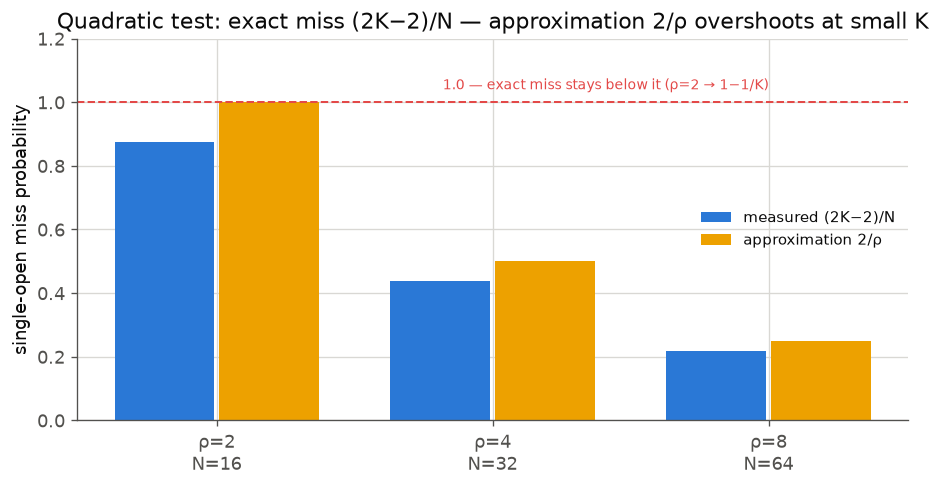

N  D_minus_1  agree  miss_measured  miss_exact
test             rho                                                 
linear (K+ELL−2) 2    16         10     10          0.625       0.625
                 4    32         10     10         0.3125      0.3125
                 8    64         10     10         0.1562      0.1562
quadratic (2K−2) 2    16         14     14          0.875       0.875
                 4    32         14     14         0.4375      0.4375
                 8    64         14     14         0.2188      0.2188

In [22]:
def agreement(Dm1, N):
    pts = domain(N); S = pts[:Dm1]; alpha = int(rng.integers(1,P,dtype=np.uint64)); hc = rand_field(Dm1)
    def Z(x):
        a = alpha
        for p in S: a = (a*((x-p)%P)) % P
        return a
    return sum(1 for x in pts if (poly_eval(hc,x)+Z(x))%P == poly_eval(hc,x)%P)

K, ELL = 8, 4; rows=[]
for name, Dm1, isquad in [("linear (K+ELL−2)", K+ELL-2, False), ("quadratic (2K−2)", 2*K-2, True)]:
    for rho in (2,4,8):
        N = rho*K
        if Dm1 > N: continue
        a = agreement(Dm1, N)
        formula = (2*K-2)/N if isquad else (K+ELL-2)/N          # exact, not 2/ρ
        rows.append(dict(test=name, rho=rho, N=N, D_minus_1=Dm1, agree=a,
                         miss_measured=a/N, miss_exact=formula))
prop_b = pd.DataFrame(rows)
assert (prop_b.agree == prop_b.D_minus_1).all()
assert np.allclose(prop_b.miss_measured, prop_b.miss_exact)      # now checks the miss, not just agree

fig, ax = plt.subplots(figsize=(7.8,4.2)); q = prop_b[prop_b.test.str.contains("quad")]
x = np.arange(len(q))
ax.bar(x-0.19, q.miss_measured, 0.36, color=PAL[0], label="measured (2K−2)/N")
ax.bar(x+0.19, [2/r for r in q.rho], 0.36, color=PAL[3], label="approximation 2/ρ")
ax.axhline(1.0, color=PAL[7], ls="--", lw=1.2)
ax.text(len(q)-1, 1.03, "1.0 — exact miss stays below it (ρ=2 → 1−1/K)", color=PAL[7], fontsize=8.5, ha="right", va="bottom")
ax.set_xticks(x); ax.set_xticklabels([f"ρ={r}\nN={n}" for r,n in zip(q.rho,q.N)])
ax.set_ylabel("single-open miss probability"); ax.set_ylim(0,1.2)
ax.set_title("Quadratic test: exact miss (2K−2)/N — approximation 2/ρ overshoots at small K")
ax.legend(frameon=False, fontsize=9, loc="center right"); plt.tight_layout(); plt.show()
prop_b.set_index(["test","rho"])

### 9.3  `T` independent opens — measured `ε` vs `(miss)^T`

The forgery escapes only if all `T` sampled columns land in the agreement set.
Sampling uniformly (with replacement), the measured escape frequency tracks
`(a/N)^T` over several orders of magnitude.

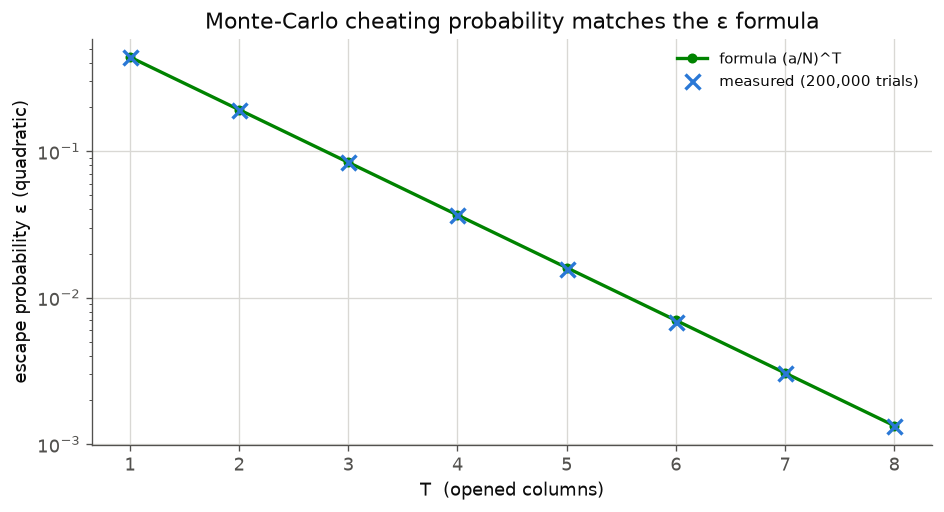

,measured ε,formula (a/N)^T
T,,
1,0.4368,0.4375
2,0.1917,0.1914
3,0.08411,0.08374
4,0.0368,0.03664
5,0.01567,0.01603
6,0.006785,0.007012
7,0.00306,0.003068
8,0.001325,0.001342


In [23]:
K, ELL, rho = 8, 4, 4; N = rho*K; a = 2*K-2; trials = 200_000
Ts = list(range(1,9)); emp, theo = [], []
for T in Ts:
    cols = rng.integers(0, N, size=(trials,T))
    emp.append(max(np.all(cols < a, axis=1).mean(), 1e-7)); theo.append((a/N)**T)
fig, ax = plt.subplots(figsize=(8.0,4.4))
ax.semilogy(Ts, theo, color=PAL[1], lw=2, marker="o", ms=5, label="formula (a/N)^T")
ax.semilogy(Ts, emp,  color=PAL[0], lw=0, marker="x", ms=9, mew=2, label=f"measured ({trials:,} trials)")
ax.set_xlabel("T  (opened columns)"); ax.set_ylabel("escape probability ε (quadratic)")
ax.set_title("Monte-Carlo cheating probability matches the ε formula")
ax.legend(frameon=False, fontsize=9); plt.tight_layout(); plt.show()
pd.DataFrame({"T":Ts, "measured ε":emp, "formula (a/N)^T":theo}).set_index("T")

### 9.4  The IRS term `(3/4)^T` — the one that actually sets `T`

9.1–9.3 validate the linear and quadratic tests (pure Schwartz–Zippel). But the
dominant term is `ε_IRS = (3/4)^T`, which comes from the Ligero **proximity** bound,
not from polynomial agreement — it is the single line that fixes `T`, and the one
place the argument leaves Schwartz–Zippel. Here it is checked by arithmetic.

Take a genuine codeword and corrupt it in `e = (ρ−1)K/3` positions (the
decoding-radius boundary the bound is stated at). Since `e < d/2`, the original is
the unique nearest codeword, so the honest low-degree polynomial the prover must
present disagrees with the committed row on exactly those `e` positions. The
per-column catch is therefore `e/N = (ρ−1)/3ρ`, i.e. miss `= 1 − (ρ−1)/3ρ = 3/4`
at `ρ = 4` — asserted against the field measurement.

In [24]:
def irs_miss(K, rho):
    N = rho*K; d = N - K + 1; e = (rho-1)*K//3
    pts = domain(N)
    cw = [poly_eval(rand_field(K), x) for x in pts]          # a genuine codeword (deg < K)
    w = cw.copy()
    for i in range(e):                                       # corrupt e positions
        w[i] = (w[i] + int(rng.integers(1, P, dtype=np.uint64))) % P
    disagree = sum(1 for a, b in zip(cw, w) if a != b)       # = catch positions vs nearest codeword
    return dict(rho=rho, N=N, d=d, e=e, unique_nearest=(e < d/2),
                catch_measured=disagree/N, catch_formula=(rho-1)/(3*rho),
                miss_measured=1-disagree/N, miss_formula=1-(rho-1)/(3*rho))

# K divisible by 3 so e = (ρ−1)K/3 is exact for both ρ (roots of unity of order
# 96 = 2^5·3 and 192 = 2^6·3 exist in Goldilocks: 2^k | 2^32 and 3 | 2^32−1).
irs = pd.DataFrame([irs_miss(24, r) for r in (4, 8)]).set_index("rho")
assert np.allclose(irs.catch_measured, irs.catch_formula) and irs.unique_nearest.all()
# and the T-fold: (miss)^T equals (3/4)^T at rho=4
assert abs(irs.loc[4,"miss_measured"]**40 - (3/4)**40) < 1e-30
irs

,N,d,e,unique_nearest,catch_measured,catch_formula,miss_measured,miss_formula
rho,,,,,,,,
4,96,73,24,True,0.25,0.25,0.75,0.75
8,192,169,56,True,0.2917,0.2917,0.7083,0.7083


## 10. Summary

| parameter | current | recommended | why |
|---|---|---|---|
| ρ | 4 | 4 | ρ=2 legal but needs ~188k columns; ρ=8 loses for the prover |
| pad | 8192 everywhere | per-block: ~128 activations, weights by recommit policy | only the weight commit needs a long masking lifetime |
| K | 2^14 | 2^16 now → 2^18 (loss ceiling) after a flat NTT kernel | √W optimum, bounded above by padding loss |
| s | 2^12 | 2^12 | optimal on overflow and accuracy both |
| T | 40 (code 80) | set by the soundness target, useful only up to ~70 | **not an optimum** — monotone in every output; capped by the floor |

**The honest bottom line.**

* **Geometry** (`K`, `pad`) collapses proof size and verifier time — but by ~18×
  within the `2^18` padding-loss ceiling, not the ~190× that only appears if you
  compare across the ceiling or across two different `λ`. Prover time barely moves
  (~1.3×); it is floored by witness recomputation, a separate lever (claim streaming).
* **Soundness is capped, and `T` is the wrong lever.** The construction floor is
  `2⁻²⁹·²`; the delivered soundness saturates ~1 bit below it (~28.3 bits), and `T`
  is fixed only once a target is named — it has no interior optimum. Because the
  protocol is **Fiat–Shamir** (non-interactive, grindable), ~28 bits is weak and the
  run's `T=40` gives only 16.6 bits (`ε≈10⁻⁵`, forgeable in seconds). The real
  levers past the ceiling are repeating the lookup challenge (→ ~58 bits) or a field
  extension — not more columns.
* **`s = 2^12` and `ρ = 4`** are genuinely forced.

Open threads worth flagging: the cost identity underestimates measured prover time
by ~2.4× (so the dollar column is a lower bound); `κ` in the quadratic-fold cost is
calibrated, not derived; padding loss bounds `K` but is not folded into the cost
formulas; and whether the deployment is interactive or Fiat–Shamir decides whether
`T` matters at all — the code path is Fiat–Shamir.